In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
apps = pd.read_csv("C:/Users/navee/Desktop/InfoByte_Pjts/L2-P4/apps.csv")
reviews = pd.read_csv("C:/Users/navee/Desktop/InfoByte_Pjts/L2-P4/user_reviews.csv")

apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [4]:
apps.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [5]:
apps.drop_duplicates(inplace=True)

In [6]:
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')

apps.dropna(subset=['Rating'], inplace=True)

In [7]:
apps['Installs'] = apps['Installs'].str.replace('+','')
apps['Installs'] = apps['Installs'].str.replace(',','')

apps['Installs'] = apps['Installs'].astype(int)

In [8]:
apps['Price'] = apps['Price'].str.replace('$','')

apps['Price'] = apps['Price'].astype(float)

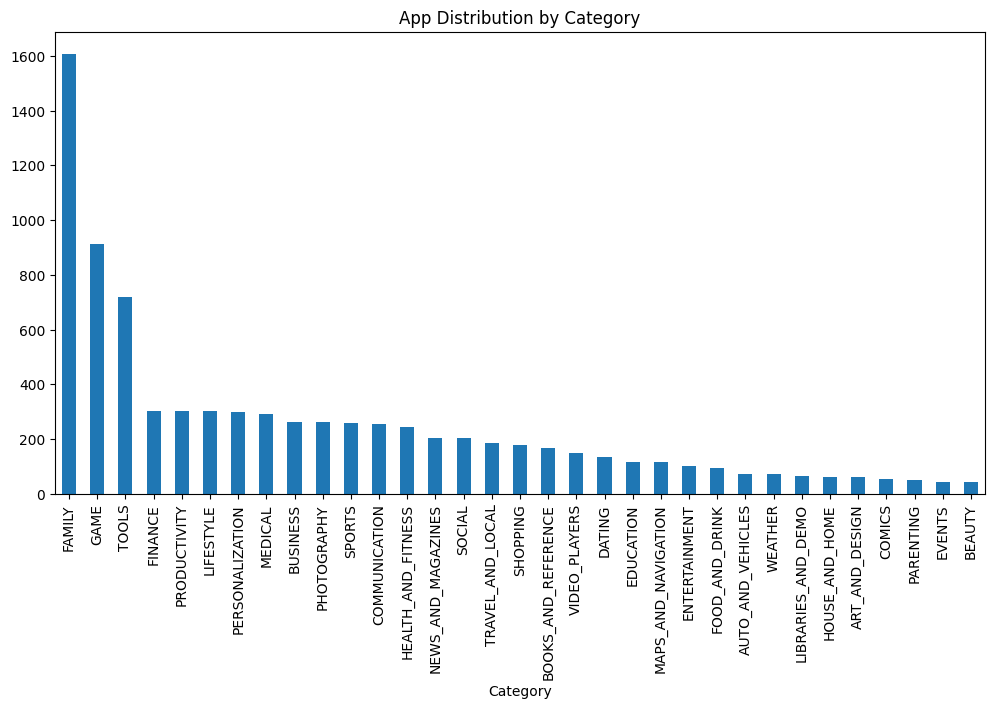

In [9]:
plt.figure(figsize=(12,6))

apps['Category'].value_counts().plot(kind='bar')

plt.title("App Distribution by Category")

plt.show()

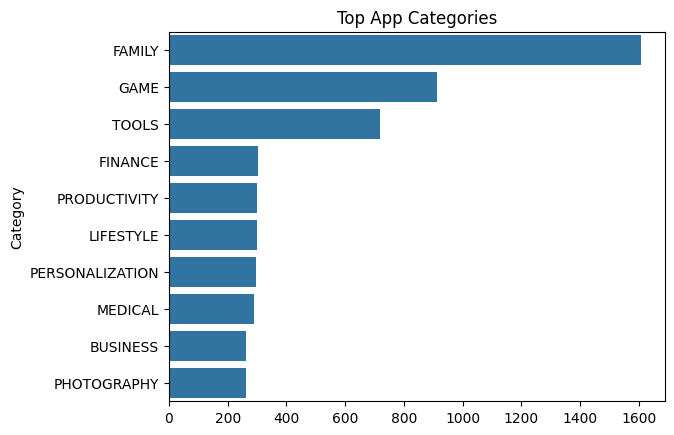

In [10]:
top_categories = apps['Category'].value_counts().head(10)

sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Top App Categories")

plt.show()

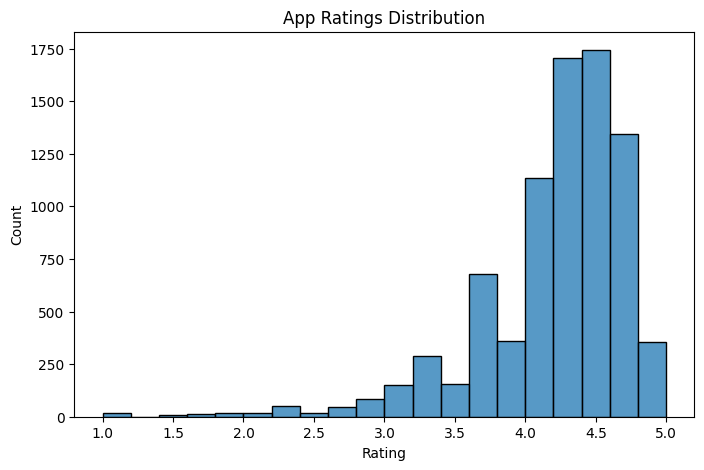

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(apps['Rating'], bins=20)

plt.title("App Ratings Distribution")

plt.show()

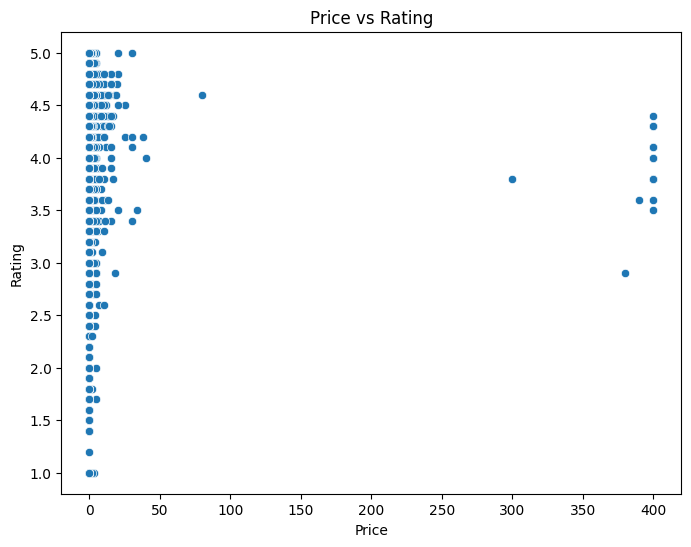

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=apps['Price'], y=apps['Rating'])

plt.title("Price vs Rating")

plt.show()

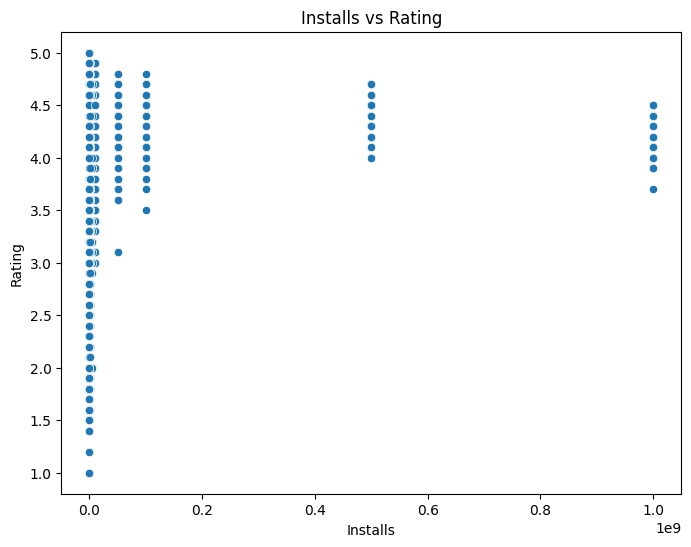

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=apps['Installs'], y=apps['Rating'])

plt.title("Installs vs Rating")

plt.show()

In [14]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


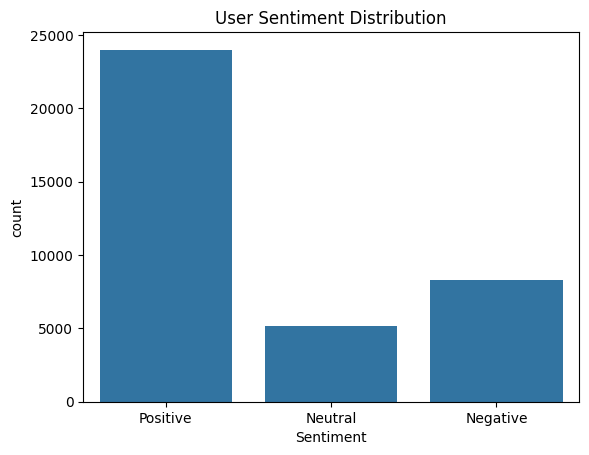

In [15]:
sns.countplot(x=reviews['Sentiment'])

plt.title("User Sentiment Distribution")

plt.show()

In [16]:
merged_df = pd.merge(apps, reviews, on='App')

merged_df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
4,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000


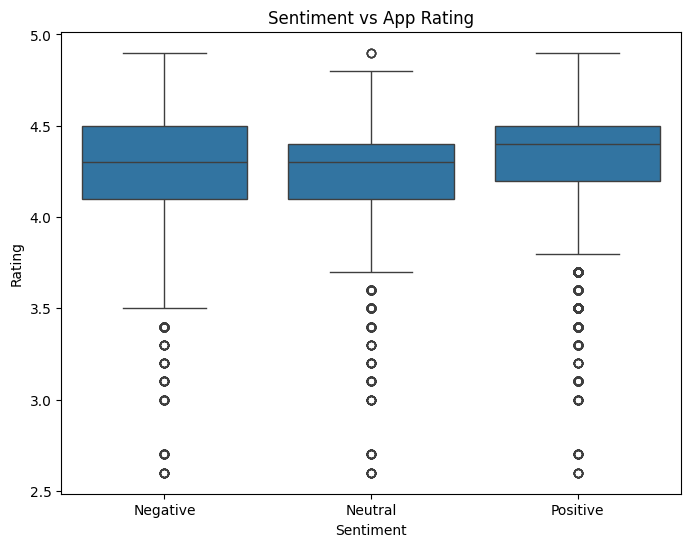

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(x=merged_df['Sentiment'], y=merged_df['Rating'])

plt.title("Sentiment vs App Rating")

plt.show()

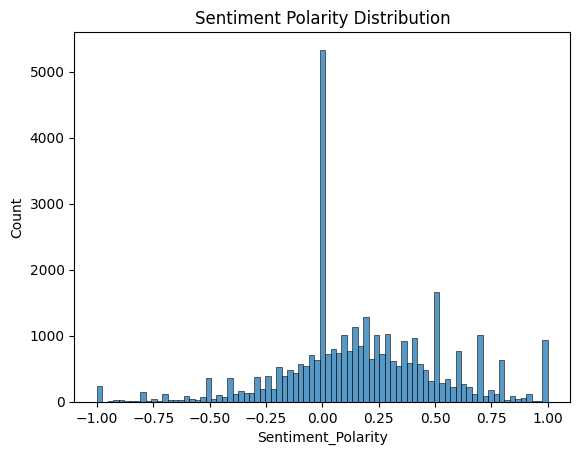

In [18]:
sns.histplot(merged_df['Sentiment_Polarity'])

plt.title("Sentiment Polarity Distribution")

plt.show()